## Topic Analysis

In [31]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, re, time
from pathlib import Path
from collections import Counter

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

plt.style.use('seaborn-v0_8-colorblind')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
c_bsky, c_truth = colors[0], colors[1]
CLEAN = Path('clean')

In [35]:
# text cleaning pipeline

STOPWORDS = set(stopwords.words('english'))
URL_RE = re.compile(r'https?://\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_RE = re.compile(r'#(\w+)')

def clean_for_topics(text):
    if not isinstance(text, str):
        return ''
    t = URL_RE.sub('', text)
    t = MENTION_RE.sub('', t)
    t = HASHTAG_RE.sub(r'\1', t)
    t = re.sub(r'[^a-zA-Z\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip().lower()
    tokens = [w for w in t.split() if w not in STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

custom_stops = set(ENGLISH_STOP_WORDS) | {
    'http', 'https', 'www', 'com', 'amp', 'rt', 'retweet',
    'truthsocial', 'bsky', 'bluesky',
    'just', 'like', 'got', 'get', 'going', 'know', 'think',
    'really', 'thing', 'things', 'people', 'would', 'could',
    'even', 'still', 'also', 'much', 'way', 'want', 'need',
    'said', 'says', 'one', 'two', 'new', 'use', 'used', 'using',
    'fuck', 'quot',
}

vectorizer_model = CountVectorizer(
    stop_words=list(custom_stops),
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
)

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
# bksy model from HPC run 

topic_model_bsky = BERTopic.load(str(CLEAN / 'bsky_top_bertopic_model'))

bsky = pd.read_csv(CLEAN / 'bsky_top_engagement.csv')
bsky['created_at'] = pd.to_datetime(bsky['created_at'], format='mixed', utc=True)
bsky = bsky.merge(pd.read_csv(CLEAN / 'bsky_top_topics.csv'), on='post_uri', how='left')
bsky = bsky.merge(pd.read_csv(CLEAN / 'bsky_top_sentiment.csv'), on='post_uri', how='left')
bsky = bsky.merge(pd.read_csv(CLEAN / 'bsky_top_emotions.csv'), on='post_uri', how='left')

print(f"Bluesky: {len(bsky):,} posts, {bsky['topic'].nunique()-1} topics, {(bsky['topic']==-1).mean()*100:.1f}% outliers")
print(f"  Sentiment: {bsky['label'].notna().sum():,}, Emotion: {bsky['labels'].notna().sum():,}")

Bluesky: 76,557 posts, 49 topics, 51.4% outliers
  Sentiment: 76,557, Emotion: 76,557


In [37]:
# truth model from HPC run 
# added additional refining for better topics - originals were not relevant / collapsing into one


# load and refit Truth Social with AI relevance filter

truth_raw = pd.read_csv(CLEAN / 'truth_posts_clean.csv', dtype={'post_id': str})
truth_raw['created_at'] = pd.to_datetime(truth_raw['created_at'], format='mixed', utc=True)

AI_TERMS = ['artificial intelligence', 'machine learning', 'chatgpt', 'openai',
            'midjourney', 'deepfake', 'chatbot', 'generative', 'llm', 'neural',
            'algorithm', 'automation', 'gpt', 'claude', 'gemini', 'copilot',
            'dall-e', 'dalle', 'stable diffusion', 'deep learning',
            'natural language', 'computer vision', 'robotic', 'robot',
            'ai model', 'ai tool', 'ai art', 'ai gen', 'ai agent',
            'ai slop', 'ai powered', 'ai ethics', 'ai water', 'ai energy']

truth = truth_raw[truth_raw['text'].apply(lambda t: any(term in str(t).lower() for term in AI_TERMS))].reset_index(drop=True)
print(f"Truth AI-relevant: {len(truth):,} / {len(truth_raw):,} ({len(truth)/len(truth_raw)*100:.1f}%)")

truth['clean_text'] = truth['text'].apply(clean_for_topics)
truth = truth[truth['clean_text'].str.len() > 10].reset_index(drop=True)
print(f"After cleaning: {len(truth):,}")

# embed and fit
truth_embeddings = embed_model.encode(truth['clean_text'].tolist(), batch_size=64, show_progress_bar=True)

topic_model_truth = BERTopic(
    embedding_model=embed_model,
    vectorizer_model=vectorizer_model,
    nr_topics=10,
    verbose=True,
)
topics_truth, _ = topic_model_truth.fit_transform(truth['clean_text'].tolist(), truth_embeddings)
truth['topic'] = topics_truth

# merge sentiment and emotion
truth = truth.merge(pd.read_csv(CLEAN / 'truth_top_sentiment.csv', dtype={'post_id': str}), on='post_id', how='left')
truth = truth.merge(pd.read_csv(CLEAN / 'truth_top_emotions.csv', dtype={'post_id': str}), on='post_id', how='left')

outliers = (pd.Series(topics_truth) == -1).mean() * 100
print(f"\nTopics: {len(set(topics_truth))-1}, Outliers: {outliers:.1f}%")
for tid in sorted(set(topics_truth)):
    if tid == -1:
        continue
    words = topic_model_truth.get_topic(tid)
    if words:
        count = (pd.Series(topics_truth) == tid).sum()
        print(f"  Topic {tid} ({count:,}): {', '.join([w[0] for w in words[:8]])}")

# save v2
topic_model_truth.save(str(CLEAN / 'truth_top_bertopic_model_v2'))
truth[['post_id', 'topic']].to_csv(CLEAN / 'truth_top_topics_v2.csv', index=False)
np.save(CLEAN / 'truth_embeddings_local_v2.npy', truth_embeddings)
print(f"\nSentiment: {truth['label'].notna().sum():,}, Emotion: {truth['labels'].notna().sum():,}")

Truth AI-relevant: 12,324 / 48,086 (25.6%)
After cleaning: 12,118


Batches:   0%|          | 0/190 [00:00<?, ?it/s]

2026-08-17 18:19:25,816 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-17 18:19:27,210 - BERTopic - Dimensionality - Completed ✓
2026-08-17 18:19:27,210 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-17 18:19:27,431 - BERTopic - Cluster - Completed ✓
2026-08-17 18:19:27,432 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-08-17 18:19:27,857 - BERTopic - Representation - Completed ✓
2026-08-17 18:19:27,857 - BERTopic - Topic reduction - Reducing number of topics
2026-08-17 18:19:27,863 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-17 18:19:28,223 - BERTopic - Representation - Completed ✓
2026-08-17 18:19:28,224 - BERTopic - Topic reduction - Reduced number of topics from 227 to 10
2026-08-17 18:19:28,319 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the mo


Topics: 9, Outliers: 35.3%
  Topic 0 (6,197): apos, china, chatgpt, trump, big, tech, robots, technology
  Topic 1 (668): art, god, video, create, prompt, poem, chatgpt, world
  Topic 2 (535): living, consciousness, time, real time, intelligence, real, traditional, advanced
  Topic 3 (183): deepfake, cgi, witness, eyes, strings, uses, develop, journey
  Topic 4 (168): kill, engage, community, group, war, join, life, humans
  Topic 5 (34): conflict, surrounding, taiwan, chatgpt, potential, ago, event, months
  Topic 6 (28): day, leap, reality, robot, make, robots, actually, elonmusk
  Topic 7 (14): publicly, party, assistant, taiwan, public, chatgpt, , 
  Topic 8 (12): assessments, testing, gpt, compliance, threat, business, solution, threats

Sentiment: 12,118, Emotion: 12,118


In [39]:
## top topics overview

TOP_N = 5

for name, df, model in [('BLUESKY', bsky, topic_model_bsky), ('TRUTH SOCIAL', truth, topic_model_truth)]:
    top_topics = df[df['topic'] != -1]['topic'].value_counts().head(TOP_N).index
    print(f"\n{name}: Top {TOP_N} Topics")
    for tid in top_topics:
        words = model.get_topic(tid)
        count = (df['topic'] == tid).sum()
        top_words = ', '.join([w[0] for w in words[:8]]) if words else 'N/A'
        print(f"  Topic {tid} ({count:,}): {top_words}")


BLUESKY: Top 5 Topics
  Topic 0.0 (8,417): aiart, midjourney, digitalart, aiartcommunity, synthart, aiartwork, aiillustration, promptart
  Topic 1.0 (4,429): data, water, students, data center, center, centers, data centers, energy
  Topic 2.0 (4,426): chatgpt, asked, asked chatgpt, openai, write, chatgpt asked, llms, ask
  Topic 3.0 (4,201): search, google, deepfake, musk, elon, chatgpt, elon musk, grok
  Topic 4.0 (2,563): genai, games, game, ghibli, fuck, art, sora, artists

TRUTH SOCIAL: Top 5 Topics
  Topic 0 (6,197): apos, china, chatgpt, trump, big, tech, robots, technology
  Topic 1 (668): art, god, video, create, prompt, poem, chatgpt, world
  Topic 2 (535): living, consciousness, time, real time, intelligence, real, traditional, advanced
  Topic 3 (183): deepfake, cgi, witness, eyes, strings, uses, develop, journey
  Topic 4 (168): kill, engage, community, group, war, join, life, humans


## Coherence Evaluation

In [40]:
## coherence scores

for name, model, df in [('Bluesky', topic_model_bsky, bsky), ('Truth Social', topic_model_truth, truth)]:
    tok = [doc.split() for doc in df['text'].dropna().apply(lambda t: ' '.join([w for w in str(t).lower().split() if len(w) > 2])).tolist()]
    d = Dictionary(tok)
    tw = []
    topic_ids = []
    for tid in sorted(set(model.topics_)):
        if tid == -1:
            continue
        words = model.get_topic(tid)
        if words:
            tw.append([w[0] for w in words[:10]])
            topic_ids.append(tid)

    cm = CoherenceModel(topics=tw, texts=tok, dictionary=d, coherence='c_v')
    overall = cm.get_coherence()
    per_topic = cm.get_coherence_per_topic()

    print(f"\n{name}")
    print(f"  Topics: {len(topic_ids)}, Outliers: {(pd.Series(model.topics_)==-1).mean()*100:.1f}%")
    print(f"  Overall c_v: {overall:.4f}")

    # top 5 topics by coherence
    scored = sorted(zip(topic_ids, per_topic, tw), key=lambda x: -x[1])
    print(f"  Top 5 by coherence:")
    for tid, score, words in scored[:5]:
        count = (pd.Series(model.topics_) == tid).sum()
        print(f"    Topic {tid} ({count:,}): c_v={score:.4f} | {', '.join(words[:6])}")

    # bottom 5 by coherence
    print(f"  Bottom 5 by coherence:")
    for tid, score, words in scored[-5:]:
        count = (pd.Series(model.topics_) == tid).sum()
        print(f"    Topic {tid} ({count:,}): c_v={score:.4f} | {', '.join(words[:6])}")


Bluesky
  Topics: 49, Outliers: 52.3%
  Overall c_v: 0.3694
  Top 5 by coherence:
    Topic 43 (13): c_v=0.7713 | investor, conference, pleased, thursday, participating, virtual
    Topic 22 (150): c_v=0.7358 | drones, ukraine, drone, powered, ukrainian, defense
    Topic 17 (263): c_v=0.6834 | blocklist, anti, block, list, blocked, lists
    Topic 5 (1,665): c_v=0.6120 | art, share, nsfw, artists, tag, tutorials
    Topic 1 (4,429): c_v=0.5826 | data, water, students, data center, center, centers
  Bottom 5 by coherence:
    Topic 46 (11): c_v=0.2056 | actress, hollywood, music, hat, released, video
    Topic 40 (14): c_v=0.2013 | washing, laundry, machine, powered, current climate, noteworthy
    Topic 0 (8,417): c_v=0.1706 | aiart, midjourney, digitalart, aiartcommunity, synthart, aiartwork
    Topic 28 (83): c_v=0.1614 | housing, andrew, chris, jorge, aoc, plan
    Topic 34 (27): c_v=0.1026 | stablediffusion, aiart, birthday, , , 

Truth Social
  Topics: 9, Outliers: 35.3%
  Overa

## Sentiment by Topic

In [41]:
## sentiment by topic - top 5

for name, df, model, color in [('Bluesky', bsky, topic_model_bsky, c_bsky),
                                ('Truth Social', truth, topic_model_truth, c_truth)]:
    top_topics = df[df['topic'] != -1]['topic'].value_counts().head(TOP_N).index
    print(f"\n{name}: Sentiment by Topic")
    for tid in top_topics:
        tp = df[df['topic'] == tid]
        words = model.get_topic(tid)
        top_words = ', '.join([w[0] for w in words[:4]]) if words else 'N/A'
        sent = tp['label'].value_counts(normalize=True) * 100
        print(f"  Topic {tid} ({len(tp):,}): {top_words}")
        print(f"    neg={sent.get('negative',0):.1f}%  neu={sent.get('neutral',0):.1f}%  pos={sent.get('positive',0):.1f}%")


Bluesky: Sentiment by Topic
  Topic 0.0 (8,417): aiart, midjourney, digitalart, aiartcommunity
    neg=2.3%  neu=70.0%  pos=27.7%
  Topic 1.0 (4,429): data, water, students, data center
    neg=55.8%  neu=33.6%  pos=10.6%
  Topic 2.0 (4,426): chatgpt, asked, asked chatgpt, openai
    neg=52.9%  neu=36.1%  pos=11.0%
  Topic 3.0 (4,201): search, google, deepfake, musk
    neg=58.6%  neu=31.0%  pos=10.4%
  Topic 4.0 (2,563): genai, games, game, ghibli
    neg=65.7%  neu=21.1%  pos=13.2%

Truth Social: Sentiment by Topic
  Topic 0 (6,197): apos, china, chatgpt, trump
    neg=19.7%  neu=53.1%  pos=27.2%
  Topic 1 (668): art, god, video, create
    neg=3.1%  neu=72.3%  pos=24.6%
  Topic 2 (535): living, consciousness, time, real time
    neg=0.0%  neu=79.4%  pos=20.6%
  Topic 3 (183): deepfake, cgi, witness, eyes
    neg=71.6%  neu=24.0%  pos=4.4%
  Topic 4 (168): kill, engage, community, group
    neg=25.0%  neu=73.2%  pos=1.8%


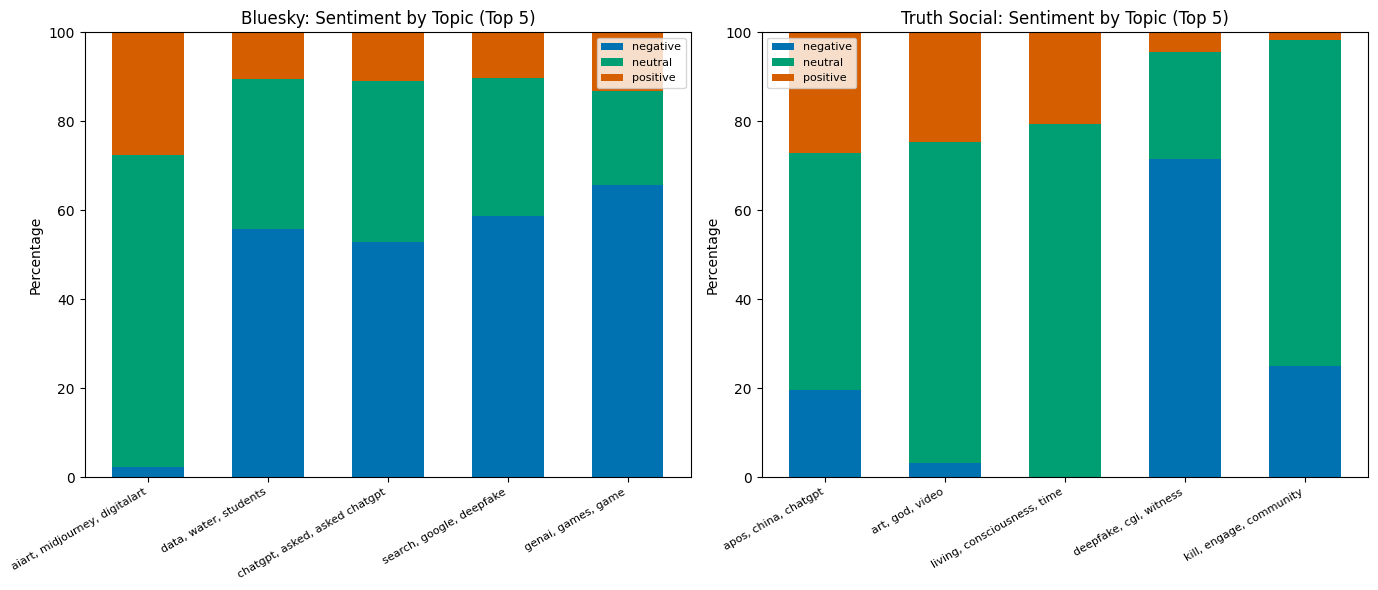

In [42]:
## sentiment by topic chart

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, df, model, name in [(ax1, bsky, topic_model_bsky, 'Bluesky'),
                              (ax2, truth, topic_model_truth, 'Truth Social')]:
    top_topics = df[df['topic'] != -1]['topic'].value_counts().head(TOP_N).index
    topic_labels = []
    sent_data = {'negative': [], 'neutral': [], 'positive': []}

    for tid in top_topics:
        words = model.get_topic(tid)
        topic_labels.append(', '.join([w[0] for w in words[:3]]) if words else f'Topic {tid}')
        tp = df[df['topic'] == tid]
        sent = tp['label'].value_counts(normalize=True) * 100
        for s in ['negative', 'neutral', 'positive']:
            sent_data[s].append(sent.get(s, 0))

    x = np.arange(len(topic_labels))
    bottom = np.zeros(len(topic_labels))
    for sentiment, values in sent_data.items():
        ax.bar(x, values, bottom=bottom, label=sentiment, width=0.6)
        bottom += np.array(values)

    ax.set_xticks(x)
    ax.set_xticklabels(topic_labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Percentage')
    ax.set_ylim(0, 100)
    ax.set_title(f'{name}: Sentiment by Topic (Top {TOP_N})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_sentiment_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()

## Emotion by Topic

In [43]:
## emotion by topic breakdown

EMOTION_ORDER = ['anger', 'disgust', 'sadness', 'anticipation', 'optimism', 'joy']

for name, df, model in [('BLUESKY', bsky, topic_model_bsky), ('TRUTH SOCIAL', truth, topic_model_truth)]:
    top_topics = df[df['topic'] != -1]['topic'].value_counts().head(TOP_N).index
    print(f"\n{name}: Emotion by Topic")
    for tid in top_topics:
        tp = df[df['topic'] == tid]
        words = model.get_topic(tid)
        top_words = ', '.join([w[0] for w in words[:4]]) if words else 'N/A'
        emo_counts = Counter(e for labels in tp['labels'].dropna() for e in labels.split('|'))
        total = sum(emo_counts.values())
        top_emo = emo_counts.most_common(3)
        print(f"  Topic {tid} ({len(tp):,}): {top_words}")
        print(f"    {', '.join(f'{e}={c/total*100:.0f}%' for e,c in top_emo)}")


BLUESKY: Emotion by Topic
  Topic 0.0 (8,417): aiart, midjourney, digitalart, aiartcommunity
    joy=43%, optimism=24%, anticipation=21%
  Topic 1.0 (4,429): data, water, students, data center
    disgust=25%, anger=24%, anticipation=19%
  Topic 2.0 (4,426): chatgpt, asked, asked chatgpt, openai
    disgust=26%, anger=24%, anticipation=14%
  Topic 3.0 (4,201): search, google, deepfake, musk
    disgust=30%, anger=30%, anticipation=13%
  Topic 4.0 (2,563): genai, games, game, ghibli
    disgust=29%, anger=29%, joy=12%

TRUTH SOCIAL: Emotion by Topic
  Topic 0 (6,197): apos, china, chatgpt, trump
    anticipation=26%, joy=22%, optimism=19%
  Topic 1 (668): art, god, video, create
    joy=51%, optimism=19%, anticipation=19%
  Topic 2 (535): living, consciousness, time, real time
    joy=35%, optimism=34%, anticipation=29%
  Topic 3 (183): deepfake, cgi, witness, eyes
    disgust=31%, anger=30%, anticipation=11%
  Topic 4 (168): kill, engage, community, group
    optimism=34%, anger=32%, 

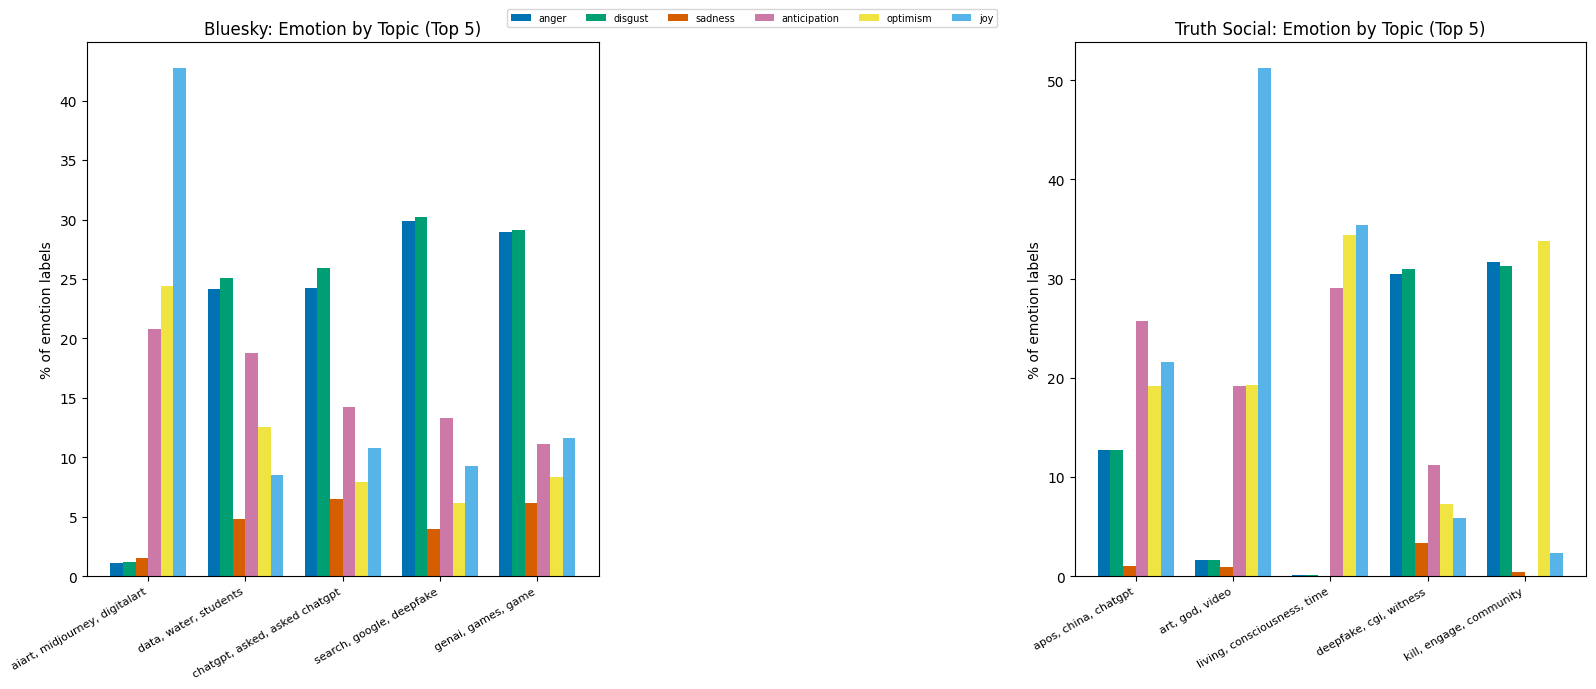

In [44]:
## emotion by topic chart

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, df, model, name in [(ax1, bsky, topic_model_bsky, 'Bluesky'),
                              (ax2, truth, topic_model_truth, 'Truth Social')]:
    top_topics = df[df['topic'] != -1]['topic'].value_counts().head(TOP_N).index
    topic_labels = []
    emotion_data = {e: [] for e in EMOTION_ORDER}

    for tid in top_topics:
        words = model.get_topic(tid)
        topic_labels.append(', '.join([w[0] for w in words[:3]]) if words else f'Topic {tid}')
        tp = df[df['topic'] == tid]
        emo_counts = Counter(e for labels in tp['labels'].dropna() for e in labels.split('|'))
        total = sum(emo_counts.values())
        for e in EMOTION_ORDER:
            emotion_data[e].append(emo_counts.get(e, 0) / total * 100 if total > 0 else 0)

    x = np.arange(len(topic_labels))
    width = 0.13
    for i, emo in enumerate(EMOTION_ORDER):
        ax.bar(x + i * width, emotion_data[emo], width, label=emo)

    ax.set_xticks(x + width * 2.5)
    ax.set_xticklabels(topic_labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('% of emotion labels')
    ax.set_title(f'{name}: Emotion by Topic (Top {TOP_N})')

ax1.legend(fontsize=7, ncol=6, loc='lower center', bbox_to_anchor=(1.3, 1.02))
plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_emotion_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# truth topics are not focused enough 
# using further ai relevance filter to compare 


AI_TERMS = ['artificial intelligence', 'machine learning', 'chatgpt', 'openai',
            'midjourney', 'deepfake', 'chatbot', 'generative', 'llm', 'neural',
            'algorithm', 'automation', 'gpt', 'claude', 'gemini', 'copilot',
            'dall-e', 'dalle', 'stable diffusion', 'deep learning',
            'natural language', 'computer vision', 'robotic', 'robot',
            'ai model', 'ai tool', 'ai art', 'ai gen', 'ai agent',
            'ai slop', 'ai powered', 'ai ethics', 'ai water', 'ai energy']

truth_ai = truth[truth['text'].apply(lambda t: any(term in str(t).lower() for term in AI_TERMS))].reset_index(drop=True)
print(f"Truth AI-relevant: {len(truth_ai):,} / {len(truth):,} ({len(truth_ai)/len(truth)*100:.1f}%)")

Truth AI-relevant: 12,118 / 12,118 (100.0%)


In [46]:
# clean text for topics
truth_ai['clean_text'] = truth_ai['text'].apply(
    lambda t: ' '.join([w for w in str(t).lower().split() if len(w) > 2])
)
truth_ai = truth_ai[truth_ai['clean_text'].str.len() > 10].reset_index(drop=True)
print(f"After cleaning: {len(truth_ai):,}")

# embed
from sentence_transformers import SentenceTransformer
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
truth_ai_embeddings = embed_model.encode(truth_ai['clean_text'].tolist(), batch_size=64, show_progress_bar=True)

# fit
topic_model_truth = BERTopic(
    embedding_model=embed_model,
    nr_topics=10,
    verbose=True,
)
topics_truth_ai, probs_truth_ai = topic_model_truth.fit_transform(truth_ai['clean_text'].tolist(), truth_ai_embeddings)

outliers = (pd.Series(topics_truth_ai) == -1).mean() * 100
print(f"\nTopics: {len(set(topics_truth_ai))-1}, Outliers: {outliers:.1f}%")
for tid in sorted(set(topics_truth_ai)):
    if tid == -1:
        continue
    words = topic_model_truth.get_topic(tid)
    if words:
        count = (pd.Series(topics_truth_ai) == tid).sum()
        print(f"  Topic {tid} ({count:,}): {', '.join([w[0] for w in words[:8]])}")

After cleaning: 12,118


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/190 [00:00<?, ?it/s]

2026-08-17 18:22:05,699 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-17 18:22:07,186 - BERTopic - Dimensionality - Completed ✓
2026-08-17 18:22:07,187 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-17 18:22:07,424 - BERTopic - Cluster - Completed ✓
2026-08-17 18:22:07,425 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-08-17 18:22:07,805 - BERTopic - Representation - Completed ✓
2026-08-17 18:22:07,805 - BERTopic - Topic reduction - Reducing number of topics
2026-08-17 18:22:07,811 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-17 18:22:08,129 - BERTopic - Representation - Completed ✓
2026-08-17 18:22:08,130 - BERTopic - Topic reduction - Reduced number of topics from 232 to 10



Topics: 9, Outliers: 36.0%
  Topic 0 (5,491): the, and, ai, com, https, chatgpt, for, with
  Topic 1 (803): the, apos, bus, you, darthmaul, 011, sony, drake
  Topic 2 (724): the, and, tcsai, quantum, quot, regenerative, system, energy
  Topic 3 (598): amp, will, are, china, big, for, the, prisons
  Topic 4 (46): disneycastle, castle, tour, aiartcommunity, continued, aiart, disney, midjourney
  Topic 5 (36): mur, tw, foreign, minister, conflict, former, the, plus
  Topic 6 (27): ukraine, khaskinwatch, vq93q5yw_iw, alexander, russia, trailer, womansbeauty, aianimation
  Topic 7 (19): csbj, and, models, doi, structural, computational, rna, org
  Topic 8 (13): fire, palisades, rindernecht, the, and, mhpx, wrought, havoc


## Emotion Heatmap

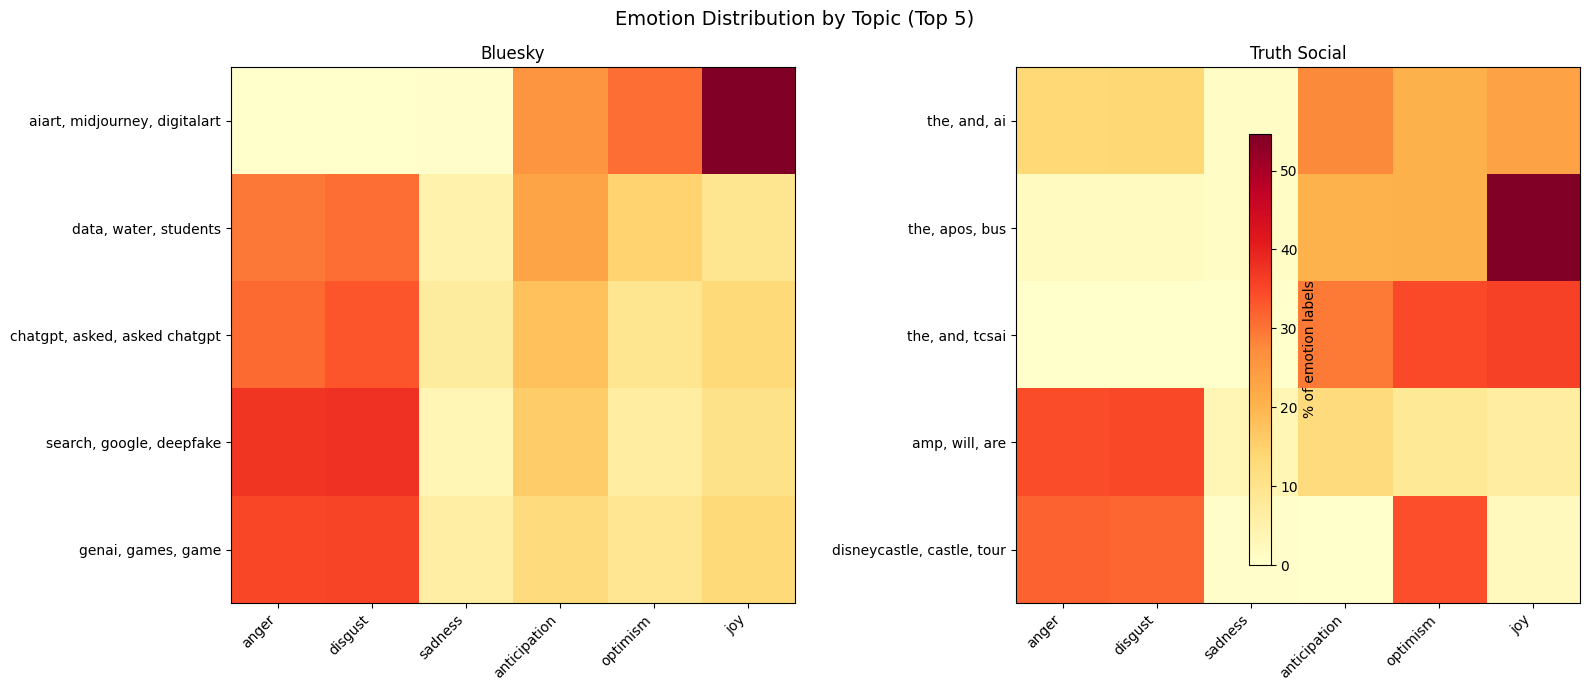

In [47]:
## topic x emotion heatmap

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, df, model, name in [(ax1, bsky, topic_model_bsky, 'Bluesky'),
                              (ax2, truth, topic_model_truth, 'Truth Social')]:
    top_topics = df[df['topic'] != -1]['topic'].value_counts().head(TOP_N).index
    emo_exploded = df[df['topic'].isin(top_topics)][['topic', 'labels']].dropna().copy()
    emo_exploded['emotion_list'] = emo_exploded['labels'].str.split('|')
    emo_exploded = emo_exploded.explode('emotion_list')
    emo_exploded = emo_exploded[emo_exploded['emotion_list'].isin(EMOTION_ORDER)]

    pivot = emo_exploded.groupby(['topic', 'emotion_list']).size().unstack(fill_value=0)
    pivot = pivot.reindex(columns=EMOTION_ORDER, fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

    # label rows with topic words
    row_labels = []
    for tid in pivot_pct.index:
        words = model.get_topic(tid)
        row_labels.append(', '.join([w[0] for w in words[:3]]) if words else f'Topic {tid}')

    im = ax.imshow(pivot_pct.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(EMOTION_ORDER)))
    ax.set_xticklabels(EMOTION_ORDER, rotation=45, ha='right')
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels)
    ax.set_title(f'{name}')

plt.colorbar(im, ax=[ax1, ax2], label='% of emotion labels', shrink=0.8)
plt.suptitle('Emotion Distribution by Topic (Top 5)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_topic_emotion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Example Posts per Emotion

In [48]:
## example posts per emotion - Bluesky

EMOTIONS = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love',
            'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

emo_df = bsky[['text', 'labels', 'label']].dropna(subset=['labels']).copy()
for emotion in EMOTIONS:
    mask = emo_df['labels'].str.contains(emotion, na=False)
    examples = emo_df[mask].sample(min(3, mask.sum()), random_state=42)
    print(f"\n{emotion.upper()} ({mask.sum():,} posts)")
    for _, row in examples.iterrows():
        print(f"  [{row['label']}] {row['text'][:150]}")


ANGER (33,339 posts)
  [negative] i encourage everyone to listen to yesterday's Knowledge Fight because Alex Jones "interviews" chatGPT and it is unhinged how badly Jones misunderstand
  [neutral] AI Boosters live in vagueness - so force them to get specific. Don't accept them suggesting *you* need to work out why ChatGPT is good: we buy softwar
  [negative] i fucking hate how people don't get that it's not about how soulless & bad genAI is or that they want to finally create a jpeg of their boring ass boo

ANTICIPATION (21,450 posts)
  [neutral] QP Your Red Dress Art. #AlArtwork #AlArt #AI #Midjourney #SynthArt #promptart #AiArtcommunity #AIArtists #Promptshare #Digitalart #QP #AIArtist #ArtOf
  [positive] I truly believe independent worker co-ops may be the way forward for some of us. And potentially as more major corporations all start looking the same
  [neutral] Why would Wisconsin approve a single AI data center without environmental and workforce protections in place?

DISGUST 

In [49]:
## example posts per emotion - Truth Social

emo_df_t = truth[['text', 'labels', 'label']].dropna(subset=['labels']).copy()
for emotion in EMOTIONS:
    mask = emo_df_t['labels'].str.contains(emotion, na=False)
    examples = emo_df_t[mask].sample(min(3, mask.sum()), random_state=42)
    print(f"\n{emotion.upper()} ({mask.sum():,} posts)")
    for _, row in examples.iterrows():
        print(f"  [{row['label']}] {row['text'][:150]}")


ANGER (3,015 posts)
  [negative] IMPORTANT - &quot;Modern Warfare&quot; 👇👇👇 DONT FALL FOR IT DONT BE CUTE - BLOCK THEM !#Foreign #intel ops are running #BOTFARMS to flood #timelines a
  [negative] How to keep racism alive where there&apos;s no racism.#HateHoax #Racism #Antisemitism #Schools #AI #DeepFake https://youtu.be/NdSEXj2Fec0?si=kn3k7lO8B
  [neutral] @realDonaldTrump Please Watch This. #realDonaldTrump#DonaldTrump#UnitedStates#America#israel#iran#Truth#Netanyahu#DeepFake#ai

ANTICIPATION (6,206 posts)
  [positive] With ChatGPT’s voice-to-text, explore a hands-free way to chat 🎙️. Dictate your queries and get quick insights—but glitches might waste your efforts 😅
  [positive] 💾 Stop Rewriting Prompts! - OCT Newsletter 12-1-2025Exciting updates in the One Cool Tip Newsletter 12-1-25! https://www.onecooltip.com/2025/12/stop-r
  [neutral] 🚨 SEO secret most agencies won&apos;t tell you:From keyword research to technical audits, content optimization to local SEO, the right prompts ca

## Example Posts per Topic

In [50]:
## example posts per topic - both platforms

for name, df, model in [('BLUESKY', bsky, topic_model_bsky), ('TRUTH SOCIAL', truth, topic_model_truth)]:
    top_topics = df[df['topic'] != -1]['topic'].value_counts().head(TOP_N).index
    print(f"\n{name}")
    for tid in top_topics:
        words = model.get_topic(tid)
        top_words = ', '.join([w[0] for w in words[:5]]) if words else 'N/A'
        tp = df[df['topic'] == tid]
        examples = tp.sample(min(3, len(tp)), random_state=42)
        print(f"\n  Topic {tid} ({len(tp):,}): {top_words}")
        for _, row in examples.iterrows():
            sent = row.get('label', '?')
            print(f"    [{sent}] {str(row['text'])[:150]}")


BLUESKY

  Topic 0.0 (8,417): aiart, midjourney, digitalart, aiartcommunity, synthart
    [neutral] #QP Your Bug Art Jump In #AiArt #AiArtCommunity #AiCommunity #MidJourney @ongajin.ai @novakynth.bsky.social @ai-visions.bsky.social @guruscorpion.bsky
    [neutral] "Goodnight Moon" #midjourney #synthart
    [neutral] More NPC work - Felara #SynthArt #GenAI #AIArt #CreativeAI #generativeart

  Topic 1.0 (4,429): data, water, students, data center, center
    [positive] helllll yessssss January 1st and I already hit my first square
    [negative] The news keeps saying the labor market is "stronger than anticipated" while long-term unemployment spikes to 2009 levels. The labor market is disinteg
    [negative] Yo, where's the AI that replaces CEOs? That can't even be hard to code. Just have it always make the greediest most shitheaded anti-human choice possi

  Topic 2.0 (4,426): chatgpt, asked, asked chatgpt, openai, write
    [neutral] Caveat emptor of course but these are some bonkers 